# Charger les librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# Charger le dataset

In [2]:
path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Inspection rapide du dataset

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


On observe que le TotalCharges est une variable object alors qu'elle devrait être en int64

# Vérifier les valeurs manquantes

In [5]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
for col in df:
    print(col, (df[col] == " ").sum())

customerID 0
gender 0
SeniorCitizen 0
Partner 0
Dependents 0
tenure 0
PhoneService 0
MultipleLines 0
InternetService 0
OnlineSecurity 0
OnlineBackup 0
DeviceProtection 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
Contract 0
PaperlessBilling 0
PaymentMethod 0
MonthlyCharges 0
TotalCharges 11
Churn 0


Il peut arriver que Kaggle cache les valeurs manquantes avec des espaces vides, le isna serait alors faussé, c'est pour cela que nous vérifions par la suite avec une somme des espaces vides par variables. On remarque alors que TotalCharges possède 11 valeurs manquantes cachées.

# Nettoyage de TotalCharges

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Après transformation de TotalCharges en integer on remarque alors les valeurs manquantes, comme elles sont peu nombreuses nous allons les supprimer.

In [14]:
df = df.dropna()

# Transformer la variable cible

Actuellement notre variable cible est sous un format object :
Churn = Yes / No
Nous voulons la transformer afin d'avoir un résultat binaire :
1 = churn 
0 = pas churn

In [15]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Vérifier les doublons

In [16]:
df.duplicated().sum()

np.int64(0)

Aucun doublons de lignes à déplorer c'est parfait

# Supprimer l'ID client

L'ID client ne nous serviras à rien pour notre modèle, nous allons donc supprimer cette colonne

In [17]:
df = df.drop(columns=["customerID"])

# Vérifier la distribution de la cible

In [18]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Nous ramarquons que ce dataset est déséquilibré mais ça n'aura normalement pas un gros impact car c'est assez faible.

# Première visualisation du churn

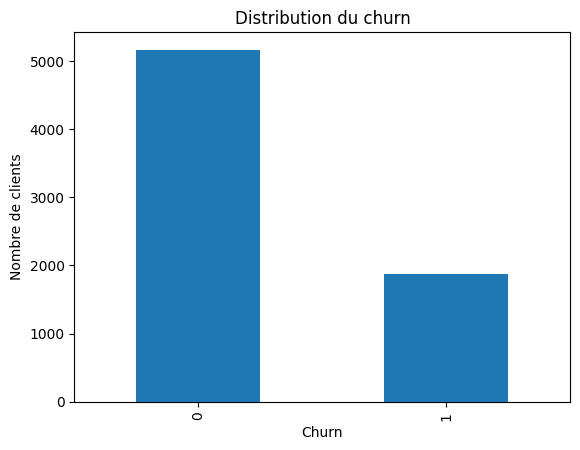

In [19]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribution du churn")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")

plt.show()

# Sauvegarder le dataset propre

In [20]:
df.to_csv("../data/processed/clean_telco_churn.csv", index=False)